# Lista 3
### NCG-040 - Introdução à Visão Computacional

**Instruções:**

 1. Comentários nos códigos desenvolvidos.
 1. Caso exista uma pergunta, deve ser respondida como comentários no arquivo ou em uma nova célula de texto.
 1. Digitar seu nome e DRE abaixo.
 1. Ao finalizarem a lista, renomeie ou salve uma cópia do arquivo no formato NomeSobrenome_ListaX.ipynb
 1. Enviar via Dropbox até 06/11/2025 - https://www.dropbox.com/request/1huYdCiFlZ6PuukcPUSq

---

`Nome: juan pedro perri barreto `

`DRE:  122030755`

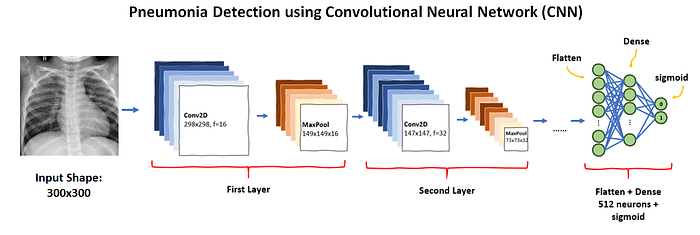

In [ ]:
mport numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from keras.preprocessing import image
import keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import RMSprop

2025-11-03 22:48:03.374938: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762210083.583453      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762210083.640510      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
# ==== 0) (opcional) variáveis de ambiente ANTES de importar TF (se estiver reiniciando o kernel) ====
# import os
# os.environ["KERAS_BACKEND"] = "tensorflow"
# os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
# os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

In [ ]:


import tensorflow as tf

# Descubra a ordem a partir do TREINO (uma vez só)
classes_fix = sorted([d for d in os.listdir("/kaggle/input/chest-xray-dataset/train")
                      if os.path.isdir(os.path.join("/kaggle/input/chest-xray-dataset/train", d))])
print("classes_fix:", classes_fix)  # ex.: ['NORMAL','PNEUMONIA','TUBERCULOSIS']

# Recrie TODOS os datasets usando a MESMA ordem:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/chest-xray-dataset/train",
    image_size=(300,300),
    batch_size=24,
    label_mode="categorical",
    class_names=classes_fix,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/chest-xray-dataset/val",
    image_size=(300,300),
    batch_size=24,
    label_mode="categorical",
    class_names=classes_fix,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/chest-xray-dataset/test",
    image_size=(300,300),
    batch_size=32,
    label_mode="categorical",
    class_names=classes_fix,
    shuffle=False
)

print("train:", train_ds.class_names)
print("val  :", val_ds.class_names)
print("test :", test_ds.class_names)


# 2) Pipeline “contido”
norm = tf.keras.layers.Rescaling(1.0 / 255.0) #normalização
PAR = 2  # paralelismo moderado (ajuste conforme RAM/CPU)

train_ds = train_ds.map(
    lambda x, y: (norm(tf.cast(x, tf.float32)), y),
    num_parallel_calls=PAR
).prefetch(1)

val_ds = val_ds.map(
    lambda x, y: (norm(tf.cast(x, tf.float32)), y),
    num_parallel_calls=PAR
).prefetch(1)

# 3) Mixed precision (opcional, mas recomendado)
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")


classes_fix: ['normal', 'pneumonia', 'tuberculosis']
Found 20450 files belonging to 3 classes.
Found 2534 files belonging to 3 classes.
Found 2569 files belonging to 3 classes.
train: ['normal', 'pneumonia', 'tuberculosis']
val  : ['normal', 'pneumonia', 'tuberculosis']
test : ['normal', 'pneumonia', 'tuberculosis']


### vemos que nossas classes estão desbalanceadas

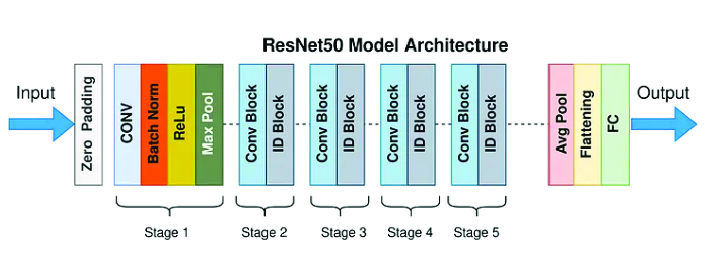![image.png](attachment:c3f349fd-4f53-4a32-a5f9-b6fa28988b07.png)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

NUM_CLASSES = 3
IMG_SIZE = (300, 300)

# 1) Base ResNet50 sem topo
base = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3)
)

# 2) Congela a base para um warmup
base.trainable = False


base.summary()



Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_2 (Cast)       │ (None, 300, 300,  │          0 │ input_layer_2[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 306, 306,  │          0 │ cast_2[0][0]      │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 150, 150,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 150, 150,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 150, 150,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 152, 152,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 75, 75,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 75, 75,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 75, 75,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 75, 75,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 75, 75,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 75, 75,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 75, 75,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 75, 75,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 75, 75,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 75, 75,    │      1,024 │ conv2_block1_0_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# 3) Cabeça de classificação
inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base(inputs, training=False)                 # importante: training=False durante warmup
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
# Em mixed precision, é bom forçar float32 na saída para estabilidade numérica
#------ lidando com o dataset desbalanceado logo vamos usar DENSE(3 CLASSES COM LOG)
counts = {name: len(glob.glob(f"/kaggle/input/chest-xray-dataset/train/{name}/*")) for name in classes_fix}
total  = sum(counts.values())
p = np.array([counts[c]/total for c in classes_fix])
bias_init = np.log(p + 1e-8) - np.log(1 - p + 1e-8)

# na cabeça:
outputs = layers.Dense(len(classes_fix), activation="softmax",
                       bias_initializer=tf.keras.initializers.Constant(bias_init),
                       dtype="float32")(x)

model = keras.Model(inputs, outputs)

# 4) Compile
opt = keras.optimizers.Adam(learning_rate=1e-4, global_clipnorm=1.0)
model.compile(
    optimizer=opt,
    loss="categorical_crossentropy",
    metrics=["accuracy"],
    steps_per_execution=32
)

### fine-tuning

In [ ]:
history1 = model.fit(
    train_ds,
    epochs=3,                    # 3–5 épocas de aquecimento costuma bastar
    validation_data=val_ds,
    verbose=1
)

# 6) Fine-tuning: destrava parte da ResNet (ex.: do stage 4 em diante)
base.trainable = True
# opcional: congele camadas iniciais para não “desaprender” filtros básicos
for layer in base.layers[:100]:   # ajuste o corte conforme memória/estabilidade
    layer.trainable = False

Epoch 1/3
853/853 ━━━━━━━━━━━━━━━━━━━━ 139s 139ms/step - accuracy: 0.3804 - loss: 1.1495 - val_accuracy: 0.4227 - val_loss: 1.0237
Epoch 2/3
853/853 ━━━━━━━━━━━━━━━━━━━━ 111s 126ms/step - accuracy: 0.4232 - loss: 1.0579 - val_accuracy: 0.4961 - val_loss: 0.9853
Epoch 3/3
853/853 ━━━━━━━━━━━━━━━━━━━━ 111s 126ms/step - accuracy: 0.4680 - loss: 1.0081 - val_accuracy: 0.5114 - val_loss: 0.9580


In [ ]:
# LR menor para fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4, global_clipnorm=1.0),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
    steps_per_execution=32
)

history2 = model.fit(
    train_ds,
    epochs =10,                   # continue a partir daqui
    validation_data=val_ds,
    verbose=1
)

Epoch 1/10
853/853 ━━━━━━━━━━━━━━━━━━━━ 182s 153ms/step - accuracy: 0.6642 - loss: 0.7164 - val_accuracy: 0.4250 - val_loss: 13.4307
Epoch 2/10
853/853 ━━━━━━━━━━━━━━━━━━━━ 112s 127ms/step - accuracy: 0.7419 - loss: 0.5038 - val_accuracy: 0.5833 - val_loss: 2.0017
Epoch 3/10
853/853 ━━━━━━━━━━━━━━━━━━━━ 112s 127ms/step - accuracy: 0.7479 - loss: 0.4676 - val_accuracy: 0.5430 - val_loss: 2.2903
Epoch 4/10
853/853 ━━━━━━━━━━━━━━━━━━━━ 113s 128ms/step - accuracy: 0.7547 - loss: 0.4381 - val_accuracy: 0.4519 - val_loss: 1.5849
Epoch 5/10
853/853 ━━━━━━━━━━━━━━━━━━━━ 115s 130ms/step - accuracy: 0.7608 - loss: 0.4392 - val_accuracy: 0.5047 - val_loss: 1.8211
Epoch 6/10
853/853 ━━━━━━━━━━━━━━━━━━━━ 113s 128ms/step - accuracy: 0.7624 - loss: 0.4241 - val_accuracy: 0.5264 - val_loss: 1.6209
Epoch 7/10
853/853 ━━━━━━━━━━━━━━━━━━━━ 112s 127ms/step - accuracy: 0.7647 - loss: 0.4199 - val_accuracy: 0.5829 - val_loss: 0.8603
Epoch 8/10
853/853 ━━━━━━━━━━━━━━━━━━━━ 112s 127ms/step - accuracy: 0.7707 

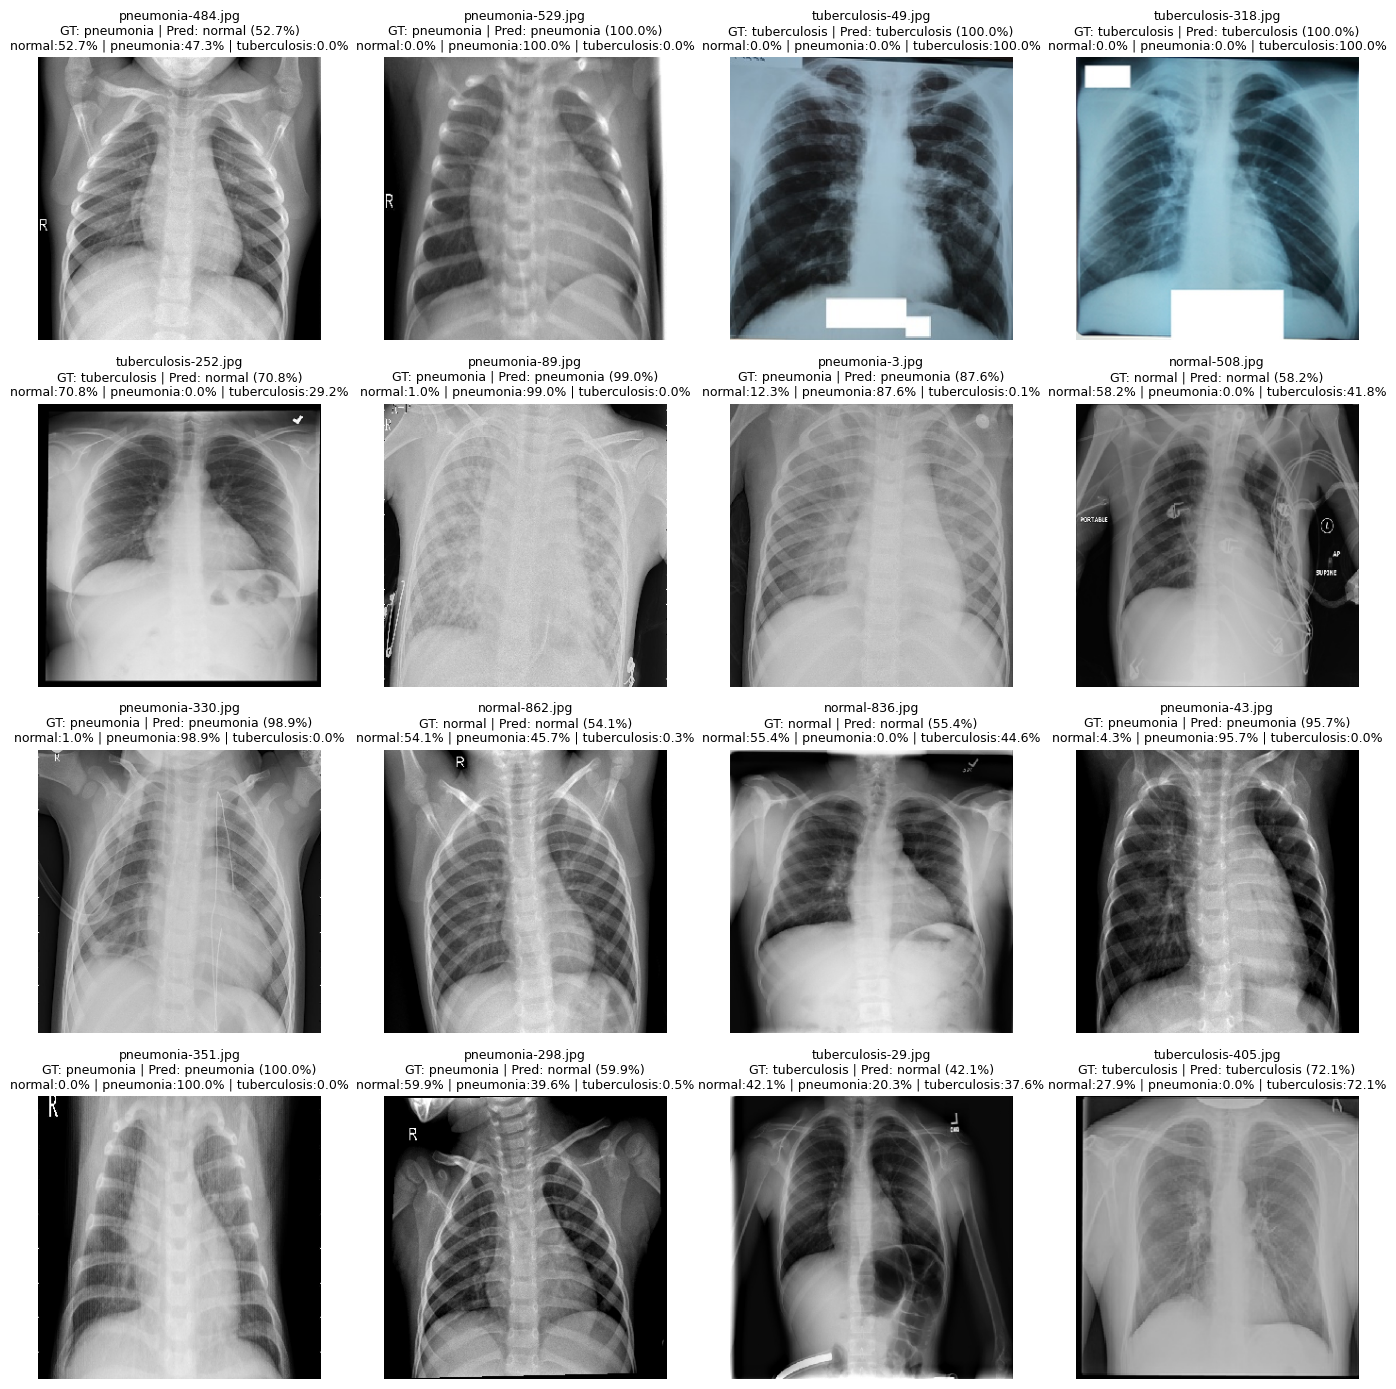

Accuracy (n=16): 0.7500
Matriz de confusão (linhas=verdade, colunas=predito):
 [[3 0 0]
 [2 6 0]
 [2 0 3]]

Relatório por classe:
              precision    recall  f1-score   support

      normal       0.43      1.00      0.60         3
   pneumonia       1.00      0.75      0.86         8
tuberculosis       1.00      0.60      0.75         5

    accuracy                           0.75        16
   macro avg       0.81      0.78      0.74        16
weighted avg       0.89      0.75      0.78        16



In [ ]:
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ------------ parâmetros ------------
IMG_SIZE = (300, 300)
N = 16                      # 4x4
RANDOM_SEED = 42            # coloque None se não quiser fixar a aleatoriedade

# ------------ paths e classes ------------
test_root = "/kaggle/input/chest-xray-dataset/test"
class_names = sorted([d for d in os.listdir(test_root) if os.path.isdir(os.path.join(test_root, d))])

patterns = ("*.png", "*.jpg", "*.jpeg")
test_files = []
for p in patterns:
    test_files.extend(glob.glob(os.path.join(test_root, "*", p)))

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)
files_16 = random.sample(test_files, min(N, len(test_files)))

# ------------ carregar lote + GT ------------
X, imgs_vis = [], []
y_true_idx, y_true_name = [], []

for f in files_16:
    gt_name = os.path.basename(os.path.dirname(f))
    y_true_name.append(gt_name)
    y_true_idx.append(class_names.index(gt_name))

    img = load_img(f, target_size=IMG_SIZE, color_mode="rgb")
    arr = img_to_array(img) / 255.0     # ajuste se seu modelo já usa Rescaling(1/255)
    imgs_vis.append(arr)
    X.append(arr)

X = np.stack(X, axis=0)  # (N,H,W,3)

# ------------ predição em batch ------------
probs = model.predict(X, verbose=0)               # (N, 3)
pred_idx = np.argmax(probs, axis=1)
pred_name = [class_names[i] for i in pred_idx]
pred_conf = probs[np.arange(len(probs)), pred_idx]

# ------------ plot 4x4 com % de TODAS as classes ------------
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.ravel()

for i, ax in enumerate(axes):
    if i >= len(files_16):
        ax.axis("off"); continue

    ax.imshow(imgs_vis[i])
    ax.axis("off")

    ok = (pred_name[i] == y_true_name[i])

    # linha 1: nome + GT/PRED
    line1 = f"{os.path.basename(files_16[i])}\nGT: {y_true_name[i]} | Pred: {pred_name[i]} ({pred_conf[i]*100:.1f}%)"
    # linha 2: porcentagens das 3 classes
    line2 = " | ".join([f"{n}:{p*100:.1f}%" for n,p in zip(class_names, probs[i])])

    ax.set_title(line1 + "\n" + line2, fontsize=9)

    # borda verde/vermelha
    for spine in ax.spines.values():
        spine.set_linewidth(3)
        spine.set_edgecolor("lime" if ok else "red")

plt.tight_layout()
plt.show()

# ------------ métricas do lote ------------
y_true = np.array(y_true_idx)
y_pred = np.array(pred_idx)

acc = accuracy_score(y_true, y_pred)
cm  = confusion_matrix(y_true, y_pred)

print(f"Accuracy (n={len(y_true)}): {acc:.4f}")
print("Matriz de confusão (linhas=verdade, colunas=predito):\n", cm)
print("\nRelatório por classe:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


In [ ]:
import tensorflow as tf

IMG_SIZE = (300, 300)
BATCH = 64

# cria um dataset a partir da pasta (mesma ordem alfabética das classes)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_root,
    labels="inferred",
    label_mode="categorical",   # one-hot
    image_size=IMG_SIZE,
    shuffle=False,
    batch_size=BATCH
)

# normalização igual ao treino (/255.0). Se você já tinha um Rescaling na primeira camada do modelo, remova esta linha.
test_ds = test_ds.map(lambda x,y: (tf.cast(x, tf.float32)/255.0, y))

# avalia: retorna [loss, acc, ...] conforme seu compile()
results = model.evaluate(test_ds, verbose=1)
print("Resultados do evaluate():", dict(zip(model.metrics_names, results)))


Found 2569 files belonging to 3 classes.
41/41 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.7524 - loss: 0.3961
Resultados do evaluate(): {'loss': 0.3952799439430237, 'compile_metrics': 0.7532113790512085}


# metricas

Found 2569 files belonging to 3 classes.
Accuracy: 0.7532
Confusion matrix:
 [[553  55 317]
 [114 465   1]
 [147   0 917]]

Classification report (per-class e médias):
              precision    recall  f1-score   support

      normal       0.68      0.60      0.64       925
   pneumonia       0.89      0.80      0.85       580
tuberculosis       0.74      0.86      0.80      1064

    accuracy                           0.75      2569
   macro avg       0.77      0.75      0.76      2569
weighted avg       0.75      0.75      0.75      2569


Macro  -> P=0.7720 R=0.7538 F1=0.7597
Weighted -> P=0.7540 R=0.7532 F1=0.7503
ROC-AUC: 0.9280


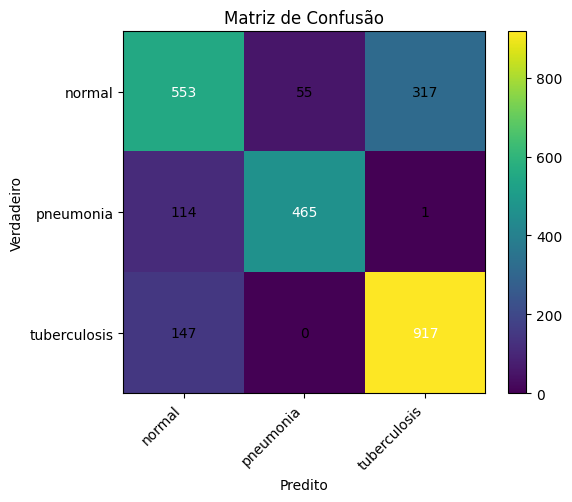

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

IMG_SIZE = (300, 300)
BATCH = 64

# 2.1) dataset de teste consistente com o treino
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_root,
    labels="inferred",
    label_mode="categorical",      # one-hot p/ multiclasses
    image_size=IMG_SIZE,
    shuffle=False,
    batch_size=BATCH
)
test_ds = test_ds.map(lambda x,y: (tf.cast(x, tf.float32)/255.0, y))

# 2.2) inferência em batches
y_true_list, y_pred_list, prob_list = [], [], []
for xb, yb in test_ds:
    probs = model.predict(xb, verbose=0)            # [B, num_classes]
    prob_list.append(probs)
    y_pred_list.append(np.argmax(probs, axis=1))    # índices preditos
    y_true_list.append(np.argmax(yb.numpy(), axis=1))

y_true = np.concatenate(y_true_list)
y_pred = np.concatenate(y_pred_list)
probs  = np.concatenate(prob_list)

# 2.3) métricas clássicas
cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

print("Accuracy:", f"{acc:.4f}")
print("Confusion matrix:\n", cm)
print("\nClassification report (per-class e médias):")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# F1 macro/weighted explicitamente, caso queira salvar os números
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
print(f"\nMacro  -> P={prec_m:.4f} R={rec_m:.4f} F1={f1_m:.4f}")
print(f"Weighted -> P={prec_w:.4f} R={rec_w:.4f} F1={f1_w:.4f}")

# 2.4) ROC-AUC (opcional)
# - Binário: usar probs[:,1]
# - Multiclasse: usar 'ovr' (one-vs-rest)
try:
    if probs.shape[1] == 2:
        auc = roc_auc_score(y_true, probs[:,1])
    else:
        # precisa de y_true one-hot para multiclasses
        y_true_oh = np.eye(len(class_names))[y_true]
        auc = roc_auc_score(y_true_oh, probs, multi_class="ovr")
    print(f"ROC-AUC: {auc:.4f}")
except Exception as e:
    print("ROC-AUC não pôde ser calculado:", e)

# 2.5) Plot da matriz de confusão
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Matriz de Confusão")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")

# anotar números
th = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > th else "black")
plt.tight_layout()
plt.show()


# backkup

In [ ]:
# salvar
model.save("/kaggle/working/chestxray_model.keras")

# carregar depois
from tensorflow import keras
model = keras.models.load_model("/kaggle/working/chestxray_model.keras")


# checkpoint

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

ckpt_best = ModelCheckpoint(
    filepath="/kaggle/working/best.keras",   # salva o modelo completo no melhor val_loss
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

ckpt_last = ModelCheckpoint(
    filepath="/kaggle/working/last.weights.h5",  # só pesos do último epoch
    save_weights_only=True,
    verbose=0
)

history = model.fit(train_ds, epochs=20, validation_data=val_ds,
                    callbacks=[ckpt_best, ckpt_last])


In [ ]:
import json

meta = {
    "class_names": class_names,      # a MESMA lista usada no treino
    "img_size": [300, 300],
    "color_mode": "rgb",
    "rescaling": True,               # se dividiu por 255 fora do modelo
    "seed": 42
}
with open("/kaggle/working/chestxray_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
